In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(pd.__version__)
print(sns.__version__)

2.2.2
0.13.2


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('merged_upi_transactions.csv')

print(df.shape)
print(df.dtypes)
print(df.head(2))

(270000, 17)
transaction_id         object
timestamp              object
transaction_type       object
merchant_category      object
amount                float64
status                 object
sender_age_group       object
receiver_age_group     object
sender_state           object
sender_bank            object
receiver_bank          object
device_type            object
payment_mode           object
city                   object
gender                 object
purpose                object
source_file            object
dtype: object
  transaction_id            timestamp transaction_type merchant_category  \
0  TXN0000000001  2024-10-08 15:17:00              P2P     Entertainment   
1  TXN0000000002  2024-04-11 06:56:00              P2M           Grocery   

   amount   status sender_age_group receiver_age_group   sender_state  \
0   868.0  SUCCESS            26-35              18-25          Delhi   
1  1011.0  SUCCESS            26-35              26-35  Uttar Pradesh   

  sender_bank 

C:\Users\abhijeet\AppData\Local\Temp\ipykernel_4760\1956898655.py:6: DtypeWarning: Columns (3,6,7,8,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('merged_upi_transactions.csv')


In [3]:
# Fix timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time dimensions
df['hour'] = df['timestamp'].dt.hour
df['day_name'] = df['timestamp'].dt.day_name()
df['month'] = df['timestamp'].dt.month_name()

# Separate DF1 and DF2
df1 = df[df['source_file'] == 'primary'].copy()
df2 = df[df['source_file'] == 'secondary'].copy()

# Verify
print(df.dtypes['timestamp'])
print(f"DF1: {df1.shape}, DF2: {df2.shape}")

# Null check
print(df.isnull().sum())

datetime64[ns]
DF1: (250000, 20), DF2: (20000, 20)
transaction_id             0
timestamp                  0
transaction_type           0
merchant_category      20000
amount                     0
status                     0
sender_age_group       20000
receiver_age_group     20000
sender_state           20000
sender_bank                0
receiver_bank              0
device_type                0
payment_mode               0
city                  250000
gender                250000
purpose               250000
source_file                0
hour                       0
day_name                   0
month                      0
dtype: int64


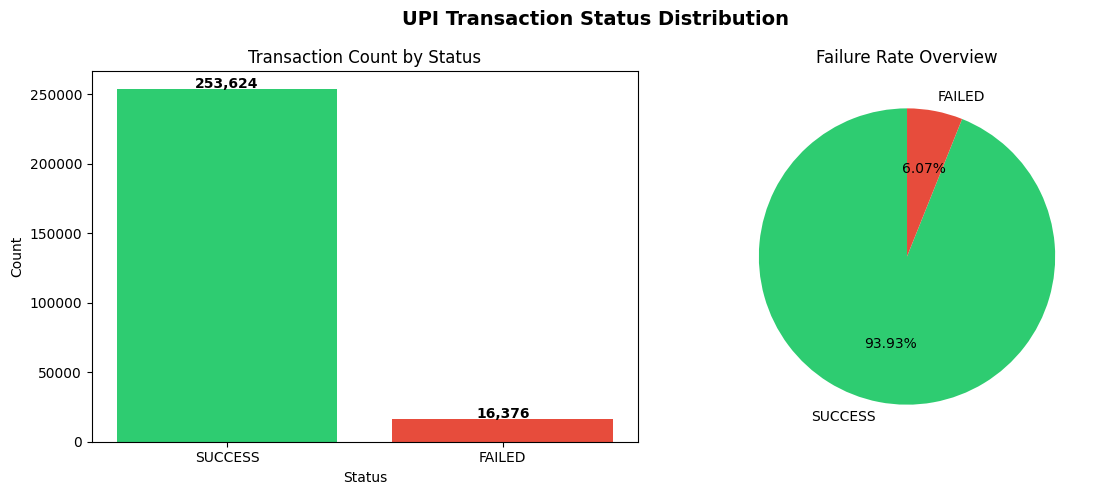

Plot 1 saved.


In [4]:
# Plot 1 — Transaction status distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('UPI Transaction Status Distribution', fontsize=14, fontweight='bold')

status_counts = df['status'].value_counts()

# Bar chart
axes[0].bar(status_counts.index, status_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Transaction Count by Status')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
for i, v in enumerate(status_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index,
            autopct='%1.2f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90)
axes[1].set_title('Failure Rate Overview')

plt.tight_layout()
plt.savefig('plot_01_status_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 saved.")

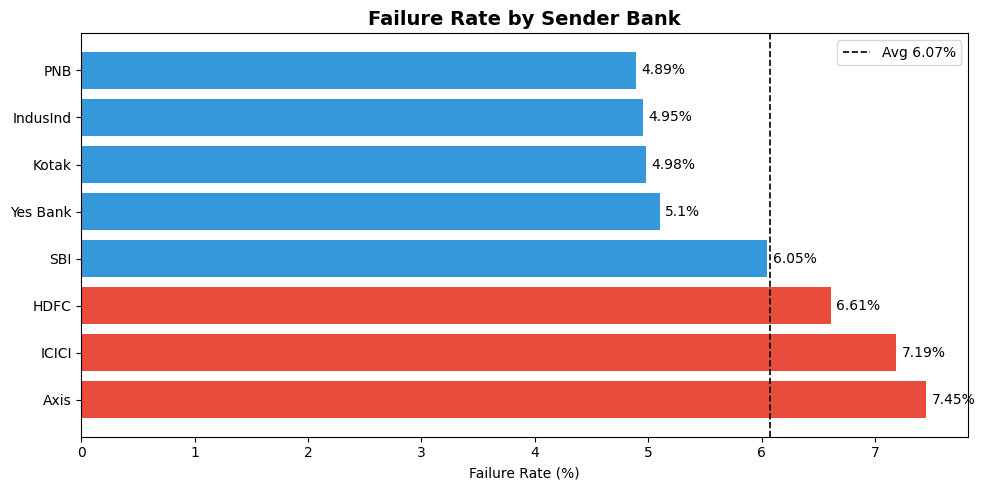

Plot 2 saved.


In [7]:
# Plot 2 — Failure rate by bank
bank_stats = df.groupby('sender_bank').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
bank_stats['failure_rate'] = round(bank_stats['failed'] * 100 / bank_stats['total'], 2)
bank_stats = bank_stats.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(bank_stats['sender_bank'], bank_stats['failure_rate'],
               color=['#e74c3c' if r > 6.07 else '#3498db' for r in bank_stats['failure_rate']])
ax.axvline(x=6.07, color='black', linestyle='--', linewidth=1.2, label='Avg 6.07%')
ax.set_title('Failure Rate by Sender Bank', fontsize=14, fontweight='bold')
ax.set_xlabel('Failure Rate (%)')
for bar, val in zip(bars, bank_stats['failure_rate']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
ax.legend()
plt.tight_layout()
plt.savefig('plot_02_bank_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 saved.")

In [6]:
# Standardize bank names from DF2
bank_name_map = {
    'SBI Bank': 'SBI',
    'ICICI Bank': 'ICICI',
    'HDFC Bank': 'HDFC',
    'Axis Bank': 'Axis'
}

df['sender_bank'] = df['sender_bank'].replace(bank_name_map)
df['receiver_bank'] = df['receiver_bank'].replace(bank_name_map)

# Verify
print(df['sender_bank'].unique())

['Axis' 'ICICI' 'Yes Bank' 'IndusInd' 'HDFC' 'Kotak' 'SBI' 'PNB']


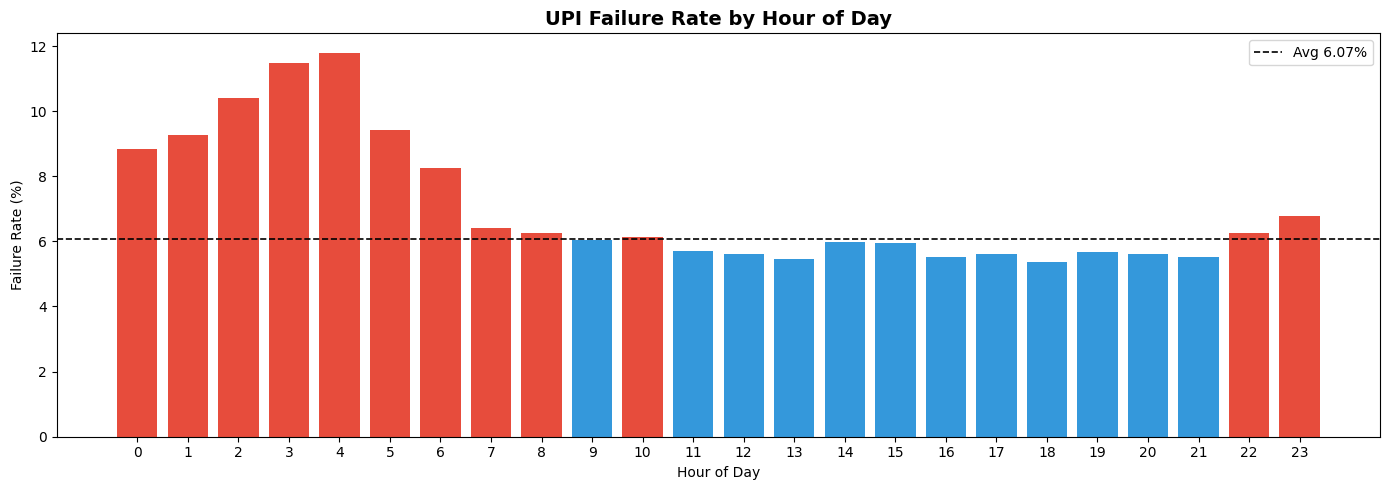

Plot 3 saved.


In [8]:
# Plot 3 — Failure rate by hour of day
hourly = df.groupby('hour').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
hourly['failure_rate'] = round(hourly['failed'] * 100 / hourly['total'], 2)

fig, ax = plt.subplots(figsize=(14, 5))
colors = ['#e74c3c' if r > 6.07 else '#3498db' for r in hourly['failure_rate']]
ax.bar(hourly['hour'], hourly['failure_rate'], color=colors)
ax.axhline(y=6.07, color='black', linestyle='--', linewidth=1.2, label='Avg 6.07%')
ax.set_title('UPI Failure Rate by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Failure Rate (%)')
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig('plot_03_hourly_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 3 saved.")

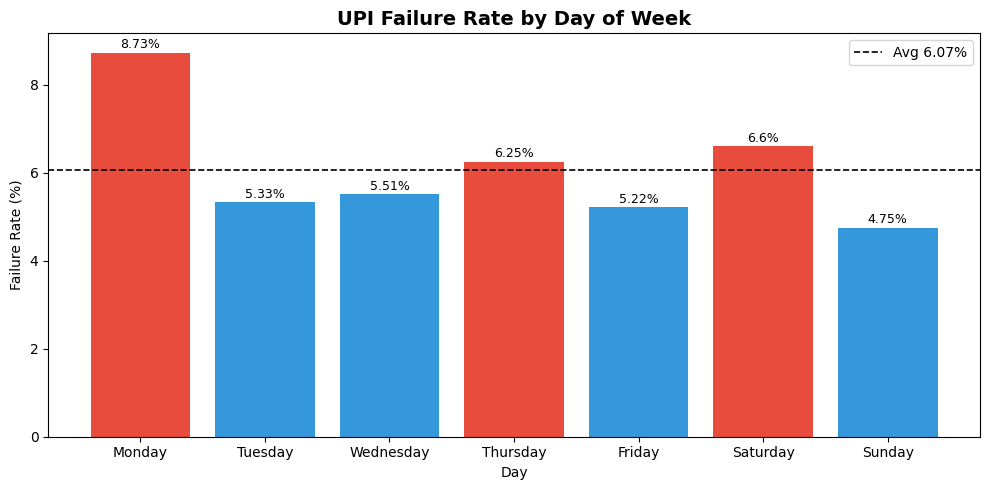

Plot 4 saved.


In [11]:
# Plot 4 — Failure rate by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

day_stats = df.groupby('day_name').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
day_stats['failure_rate'] = round(day_stats['failed'] * 100 / day_stats['total'], 2)
day_stats['day_name'] = pd.Categorical(day_stats['day_name'], categories=day_order, ordered=True)
day_stats = day_stats.sort_values('day_name')

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if r > 6.07 else '#3498db' for r in day_stats['failure_rate']]
bars = ax.bar(day_stats['day_name'], day_stats['failure_rate'], color=colors)
ax.axhline(y=6.07, color='black', linestyle='--', linewidth=1.2, label='Avg 6.07%')
ax.set_title('UPI Failure Rate by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Failure Rate (%)')
for bar, val in zip(bars, day_stats['failure_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.1, f'{val}%', ha='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('plot_04_day_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 4 saved.")

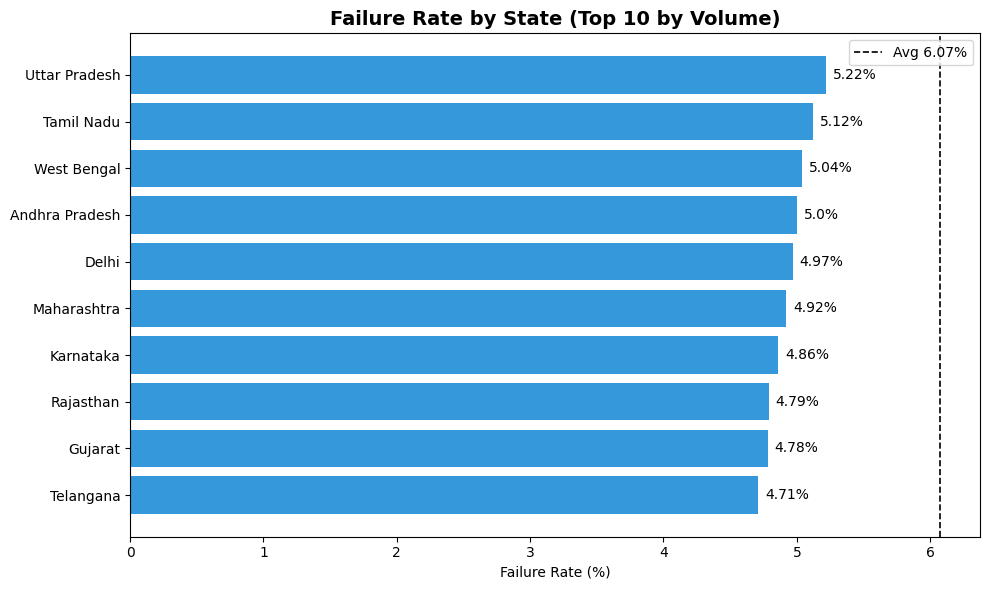

Plot 5 saved.


In [10]:
# Plot 5 — Failure rate by state (top 10 by volume)
state_stats = df1.groupby('sender_state').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
state_stats['failure_rate'] = round(state_stats['failed'] * 100 / state_stats['total'], 2)
state_stats = state_stats.sort_values('total', ascending=False).head(10)
state_stats = state_stats.sort_values('failure_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if r > 6.07 else '#3498db' for r in state_stats['failure_rate']]
bars = ax.barh(state_stats['sender_state'], state_stats['failure_rate'], color=colors)
ax.axvline(x=6.07, color='black', linestyle='--', linewidth=1.2, label='Avg 6.07%')
ax.set_title('Failure Rate by State (Top 10 by Volume)', fontsize=14, fontweight='bold')
ax.set_xlabel('Failure Rate (%)')
for bar, val in zip(bars, state_stats['failure_rate']):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
ax.legend()
plt.tight_layout()
plt.savefig('plot_05_state_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 5 saved.")

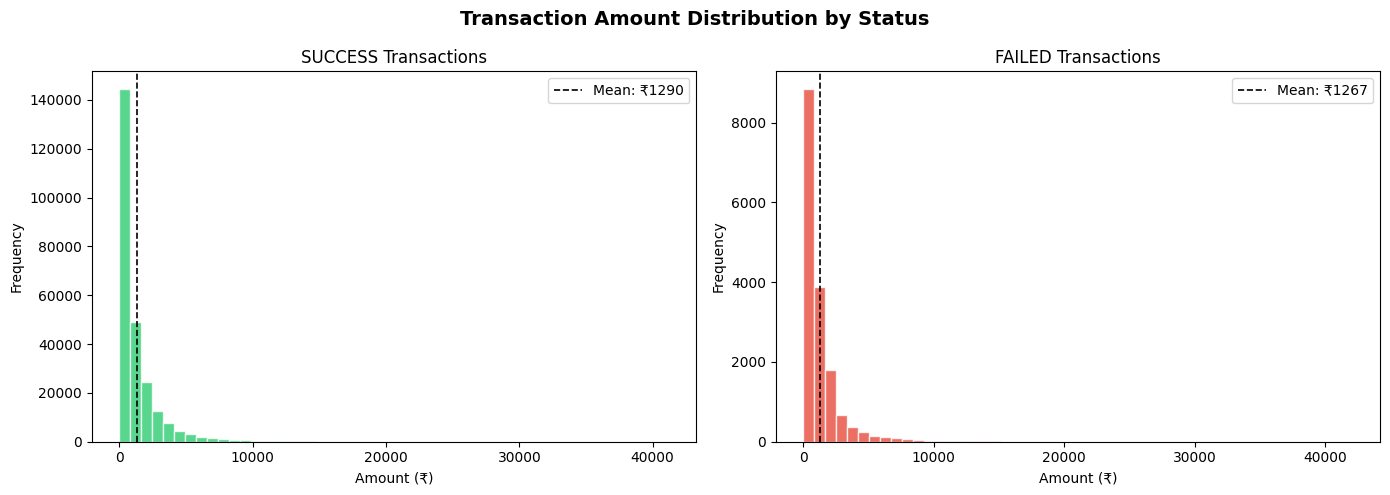

Plot 6 saved.


In [12]:
# Plot 6 — Transaction amount distribution by status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transaction Amount Distribution by Status', fontsize=14, fontweight='bold')

for ax, status, color in zip(axes, ['SUCCESS', 'FAILED'], ['#2ecc71', '#e74c3c']):
    data = df[df['status'] == status]['amount']
    ax.hist(data, bins=50, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Mean: ₹{data.mean():.0f}')
    ax.set_title(f'{status} Transactions')
    ax.set_xlabel('Amount (₹)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('plot_06_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 6 saved.")

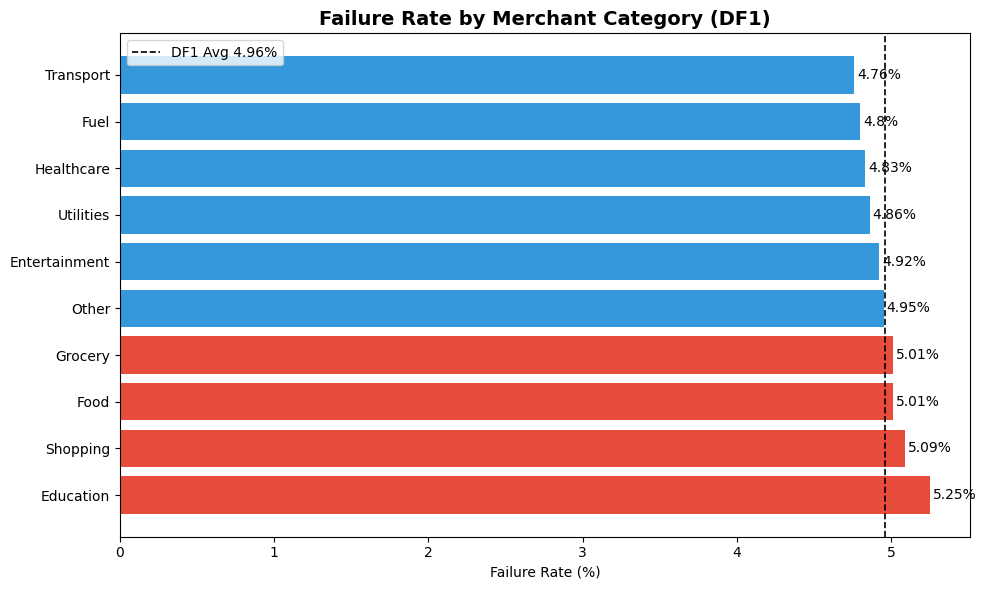

Plot 7 saved.


In [13]:
# Plot 7 — Failure rate by merchant category (DF1 only)
merchant_stats = df1.groupby('merchant_category').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
merchant_stats['failure_rate'] = round(merchant_stats['failed'] * 100 / merchant_stats['total'], 2)
merchant_stats = merchant_stats.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if r > 4.96 else '#3498db' for r in merchant_stats['failure_rate']]
bars = ax.barh(merchant_stats['merchant_category'], merchant_stats['failure_rate'], color=colors)
ax.axvline(x=4.96, color='black', linestyle='--', linewidth=1.2, label='DF1 Avg 4.96%')
ax.set_title('Failure Rate by Merchant Category (DF1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Failure Rate (%)')
for bar, val in zip(bars, merchant_stats['failure_rate']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f'{val}%', va='center')
ax.legend()
plt.tight_layout()
plt.savefig('plot_07_merchant_failure_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 7 saved.")

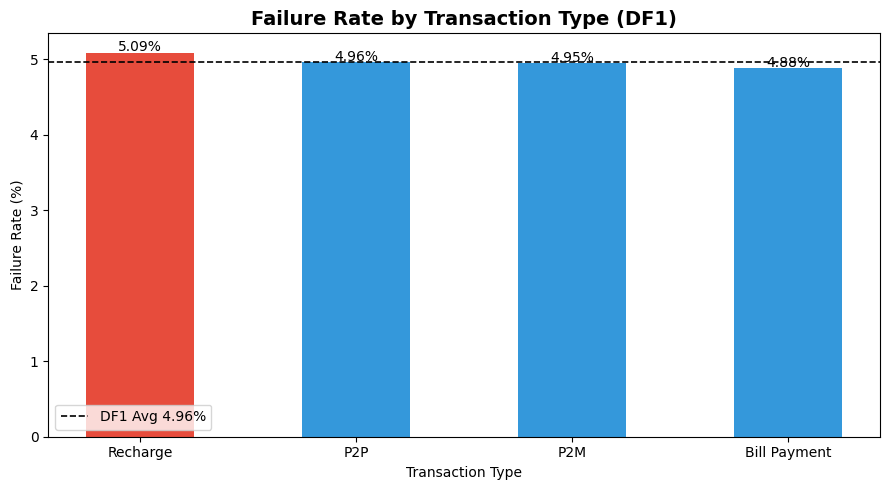

Plot 8 saved.


In [14]:
# Plot 8 — Failure rate by transaction type (DF1 only)
type_stats = df1.groupby('transaction_type').agg(
    total=('status', 'count'),
    failed=('status', lambda x: (x == 'FAILED').sum())
).reset_index()
type_stats['failure_rate'] = round(type_stats['failed'] * 100 / type_stats['total'], 2)
type_stats = type_stats.sort_values('failure_rate', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if r > 4.96 else '#3498db' for r in type_stats['failure_rate']]
bars = ax.bar(type_stats['transaction_type'], type_stats['failure_rate'], color=colors, width=0.5)
ax.axhline(y=4.96, color='black', linestyle='--', linewidth=1.2, label='DF1 Avg 4.96%')
ax.set_title('Failure Rate by Transaction Type (DF1)', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Failure Rate (%)')
for bar, val in zip(bars, type_stats['failure_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val}%', ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('plot_08_transaction_type_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 8 saved.")

C:\Users\abhijeet\AppData\Local\Temp\ipykernel_4760\3059915076.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['status'] == 'FAILED').sum() / len(x) * 100)


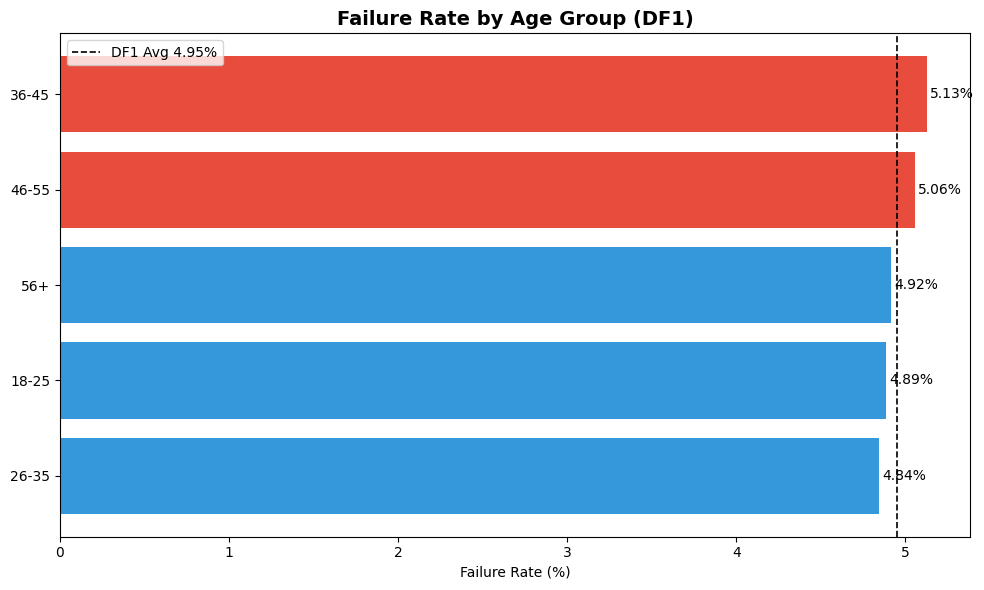

Plot 9 saved.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# DF1 age group failure rate
age_failure = (
    df1.groupby('sender_age_group')
    .apply(lambda x: (x['status'] == 'FAILED').sum() / len(x) * 100)
    .reset_index()
)
age_failure.columns = ['age_group', 'failure_rate']
age_failure = age_failure.sort_values('failure_rate', ascending=True)

df1_avg = (df1['status'] == 'FAILED').sum() / len(df1) * 100  # 4.96%

colors = ['#E74C3C' if r > df1_avg else '#3498DB' for r in age_failure['failure_rate']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(age_failure['age_group'], age_failure['failure_rate'], color=colors)

for bar, val in zip(bars, age_failure['failure_rate']):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=10)

ax.axvline(df1_avg, color='black', linestyle='--', linewidth=1.2,
           label=f'DF1 Avg {df1_avg:.2f}%')

ax.set_xlabel('Failure Rate (%)')
ax.set_title('Failure Rate by Age Group (DF1)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plot_09_age_group_failure.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 9 saved.")

C:\Users\abhijeet\AppData\Local\Temp\ipykernel_4760\4198412374.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: (x['status'] == 'FAILED').sum() / len(x) * 100)


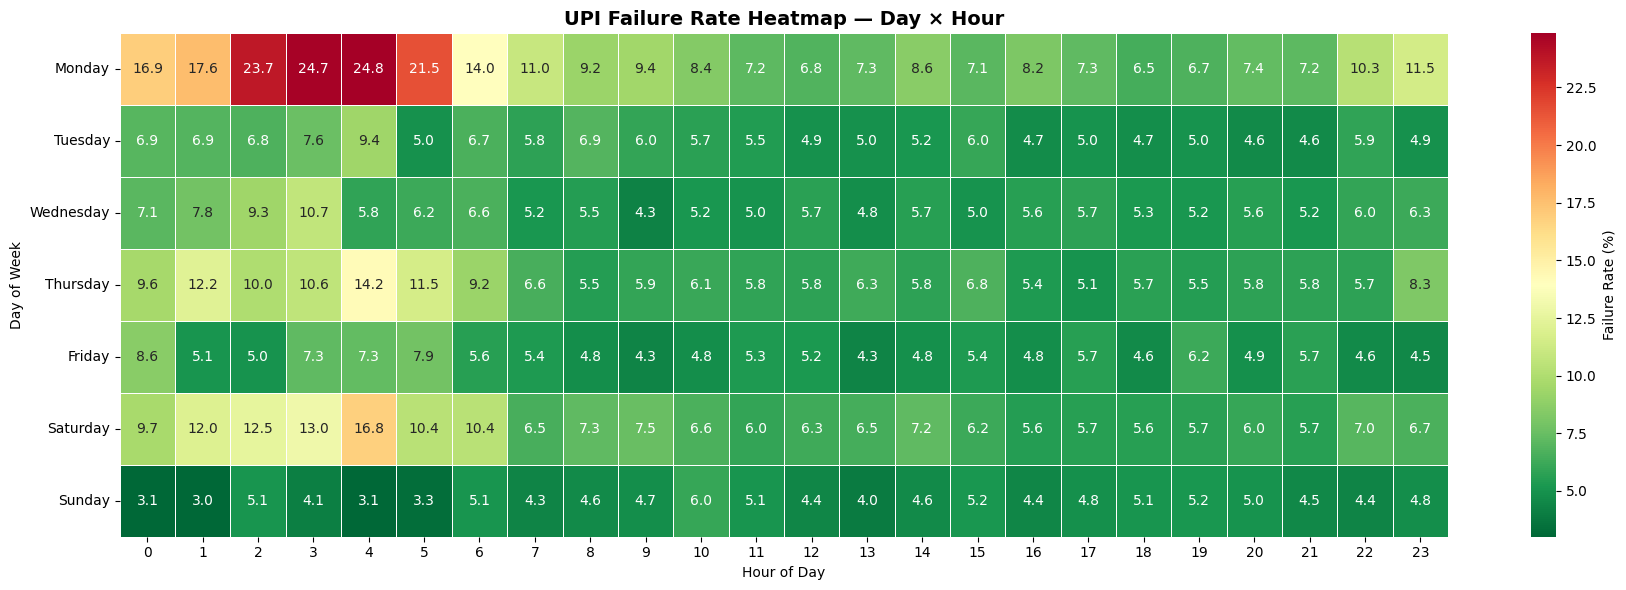

Plot 10 saved.


In [16]:
import seaborn as sns
import numpy as np

# Build pivot table
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = (
    df.groupby(['day_name', 'hour'])
    .apply(lambda x: (x['status'] == 'FAILED').sum() / len(x) * 100)
    .reset_index()
)
heatmap_data.columns = ['day_name', 'hour', 'failure_rate']

pivot = heatmap_data.pivot(index='day_name', columns='hour', values='failure_rate')
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(
    pivot,
    cmap='RdYlGn_r',
    annot=True,
    fmt='.1f',
    linewidths=0.4,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Failure Rate (%)'}
)

ax.set_title('UPI Failure Rate Heatmap — Day × Hour', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('plot_10_day_hour_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot 10 saved.")